# E0 — Естественная межкорпусная неоднородность

Этот ноутбук оценивает, образуют ли CREMA-D, RAVDESS и SAVEE статистически различимые домены ещё до сравнения методов. Задача остаётся бинарной: `ANG=1`, любая другая поддерживаемая эмоция — `0`.

Используемые свидетельства:
- сводки по записям, актёрам, классам, ошибкам извлечения и длительности;
- распределения RMS, ZCR и MFCC до и после локальной для корпуса стандартизации, рассчитанной только по обучающей части;
- расхождение Йенсена — Шеннона для долей классов;
- расстояния Вассерштейна и энергетические расстояния, а также двухвыборочные KS-тесты для скалярных признаков;
- многомерный RBF-MMD с перестановочным p-значением;
- попарный ROC-AUC классификации домена с кросс-валидацией, сгруппированной по актёрам;
- графики PCA только в качестве описательной иллюстрации.

Ни один отдельный тест не доказывает, что данные являются non-IID. Размеры эффектов, неопределённость, скорректированные p-значения и результат классификации домена следует рассматривать совместно.

In [1]:
from itertools import combinations
from pathlib import Path

import os
import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.spatial.distance import jensenshannon
from scipy.stats import energy_distance, ks_2samp, wasserstein_distance
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from src.dataset.analytics import DataConcatenator
from src.dataset.processors.factory import DatasetLoaderFactory
from src.schema import ConfigSchema
from src.utils.config import read_yaml

In [2]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

os.chdir(PROJECT_ROOT)

In [3]:
sns.set_theme(style='whitegrid')
SEED = 42
N_PERMUTATIONS = 499
MAX_MMD_SAMPLES_PER_CORPUS = 500
CONFIG_PATH = Path('configs/experiments/config.e0.yaml')
if not CONFIG_PATH.exists():
    raise FileNotFoundError(
        'Create untracked configs/config.yaml with valid dataset roots first.'
    )

In [4]:
config = ConfigSchema(**read_yaml(CONFIG_PATH))

## Загрузка воспроизводимых сводок по выборкам

Загрузчик репозитория предоставляет метки, идентификаторы актёров, число потерь при извлечении и настроенные акустические признаки. Корневые каталоги наборов данных и порядок признаков берутся из провалидированной локальной конфигурации. Длительность независимо считывается из заголовков WAV, поэтому её покрытие указывается отдельно от успешно извлечённых признаков.

In [5]:
frames = []
reports = []
duration_rows = []

for client in config.clients:
    dataset_config = client.dataset
    loader = DatasetLoaderFactory.create(dataset_config)
    features, metadata = loader.load(feature_mode='multi_channel')
    aggregate = DataConcatenator([dataset_config]).aggregate_features(
        features, dataset_config.feature_names
    )
    frame = DataConcatenator([dataset_config]).to_dataframe(aggregate, metadata)
    frame['dataset'] = dataset_config.name.value
    frame['client_id'] = client.client_id
    frames.append(frame)
    reports.append({'dataset': dataset_config.name.value, **loader.last_load_report})

    wav_paths = sorted(Path(dataset_config.root).rglob('*.wav'))
    if dataset_config.reduced:
        wav_paths = wav_paths[: dataset_config.reduced_size or 1000]
    for path in wav_paths:
        try:
            duration_rows.append({
                'dataset': dataset_config.name.value,
                'duration_sec': float(librosa.get_duration(path=path)),
            })
        except Exception:
            duration_rows.append({
                'dataset': dataset_config.name.value,
                'duration_sec': np.nan,
            })

samples = pd.concat(frames, ignore_index=True)
durations = pd.DataFrame(duration_rows)
extraction_report = pd.DataFrame(reports).set_index('dataset')
feature_columns = [
    column for column in samples.columns
    if column.endswith(('_mean', '_std'))
]
print(f'Loaded {len(samples):,} feature rows and {len(feature_columns)} summaries')
display(extraction_report)

INFO:src.dataset.processors.factory:Loading dataset DatasetType.crema_d
INFO:splitfed_asr:Loading data from /home/blasterss/Splitfed-speech-classification/../datasets/CREMA-D/raw...
Loading DatasetType.crema_d:   0%|          | 0/7442 [00:00<?, ?file/s]/home/blasterss/Splitfed-speech-classification/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading DatasetType.crema_d: 100%|██████████| 7442/7442 [01:19<00:00, 93.63file/s] 
INFO:splitfed_asr:Loading completed. Total files: 7442
INFO:splitfed_asr:Multi-channel features:
INFO:splitfed_asr:  FeatureType.mfcc: (13, 143)
INFO:splitfed_asr:  FeatureType.rms: (1, 143)
INFO:splitfed_asr:  FeatureType.zcr: (1, 143)
INFO:src.dataset.processors.factory:Loading dataset DatasetType.ravdess
INFO:splitfed_asr:Loading data from /home/blasterss/Splitfed-speech

Loaded 9,362 feature rows and 30 summaries


,discovered,loaded,failed,failure_reasons
dataset,,,,
CREMA-D,7442,7442,0,{}
RAVDESS,1440,1440,0,{}
SAVEE,480,480,0,{}


In [6]:
sample_summary = samples.groupby('dataset').agg(
    samples=('label', 'size'),
    actors=('actor_id', 'nunique'),
    anger=('label', 'sum'),
)
sample_summary['non_anger'] = sample_summary['samples'] - sample_summary['anger']
sample_summary['anger_share'] = sample_summary['anger'] / sample_summary['samples']
duration_summary = durations.groupby('dataset')['duration_sec'].agg(
    duration_count='count', duration_mean='mean', duration_std='std',
    duration_median='median', duration_min='min', duration_max='max',
)
summary = sample_summary.join(duration_summary).join(extraction_report)
display(summary.round(4))

,samples,actors,anger,non_anger,anger_share,duration_count,duration_mean,duration_std,duration_median,duration_min,duration_max,discovered,loaded,failed,failure_reasons
dataset,,,,,,,,,,,,,,,
CREMA-D,7442,91,1271,6171,0.1708,7442,2.5429,0.5060,2.5025,1.2679,5.0050,7442,7442,0,{}
RAVDESS,1440,24,192,1248,0.1333,1440,3.7007,0.3367,3.6703,2.9363,5.2719,1440,1440,0,{}
SAVEE,480,4,60,420,0.1250,480,3.8395,1.0780,3.6730,1.6309,7.1387,480,480,0,{}


## Сдвиг меток и скалярных признаков

Расстояние Йенсена — Шеннона ограничено и симметрично. Расстояния Вассерштейна и энергетические расстояния выражают размер эффекта в единицах признака; KS-тест не требует предположения о виде распределения, но сильно зависит от размера выборки. Поправка Бенджамини — Хохберга контролирует долю ложных открытий среди всех KS-тестов для пар корпусов и признаков.

In [7]:
def benjamini_hochberg(p_values):
    values = np.asarray(p_values, dtype=float)
    order = np.argsort(values)
    ranked = values[order]
    adjusted = np.minimum.accumulate(
        (ranked * len(values) / np.arange(1, len(values) + 1))[::-1]
    )[::-1]
    result = np.empty_like(adjusted)
    result[order] = np.clip(adjusted, 0, 1)
    return result

datasets = sorted(samples['dataset'].unique())
label_rows = []
for left, right in combinations(datasets, 2):
    p = samples.loc[samples.dataset == left, 'label'].value_counts(normalize=True)
    q = samples.loc[samples.dataset == right, 'label'].value_counts(normalize=True)
    support = [0, 1]
    label_rows.append({
        'left': left, 'right': right,
        'js_distance': jensenshannon(
            p.reindex(support, fill_value=0), q.reindex(support, fill_value=0), base=2
        ),
    })
display(pd.DataFrame(label_rows).round(4))

scalar_rows = []
for left, right in combinations(datasets, 2):
    for feature in feature_columns:
        x = samples.loc[samples.dataset == left, feature].dropna().to_numpy()
        y = samples.loc[samples.dataset == right, feature].dropna().to_numpy()
        ks = ks_2samp(x, y)
        scalar_rows.append({
            'left': left, 'right': right, 'feature': feature,
            'wasserstein': wasserstein_distance(x, y),
            'energy': energy_distance(x, y),
            'ks_statistic': ks.statistic, 'ks_p': ks.pvalue,
        })
scalar_shift = pd.DataFrame(scalar_rows)
scalar_shift['ks_q_bh'] = benjamini_hochberg(scalar_shift['ks_p'])
display(scalar_shift.sort_values('wasserstein', ascending=False).head(30).round(5))

,left,right,js_distance
0,CREMA-D,RAVDESS,0.0443
1,CREMA-D,SAVEE,0.0549
2,RAVDESS,SAVEE,0.0106


,left,right,feature,wasserstein,energy,ks_statistic,ks_p,ks_q_bh
0,CREMA-D,RAVDESS,mfcc_0_mean,231.70093,17.15091,0.89300,0.0,0.0
60,RAVDESS,SAVEE,mfcc_0_mean,198.42061,13.69991,0.66528,0.0,0.0
1,CREMA-D,RAVDESS,mfcc_0_std,91.55702,11.20790,0.91366,0.0,0.0
2,CREMA-D,RAVDESS,mfcc_1_mean,72.51503,10.27427,0.94640,0.0,0.0
62,RAVDESS,SAVEE,mfcc_1_mean,57.61605,8.52748,0.88333,0.0,0.0
30,CREMA-D,SAVEE,mfcc_0_mean,54.15620,4.40193,0.24684,0.0,0.0
61,RAVDESS,SAVEE,mfcc_0_std,53.11678,8.12766,0.82986,0.0,0.0
31,CREMA-D,SAVEE,mfcc_0_std,38.44095,5.77499,0.61171,0.0,0.0
4,CREMA-D,RAVDESS,mfcc_2_mean,29.51805,5.86615,0.78486,0.0,0.0
64,RAVDESS,SAVEE,mfcc_2_mean,28.00149,5.44290,0.73333,0.0,0.0


## До и после локальной стандартизации по обучающей части корпуса

Актёры разделяются строго в соответствии с настроенным для каждого набора данных `split_seed`. Статистики рассчитываются только по обучающим актёрам соответствующего корпуса. Эта ячейка стандартизирует агрегированные диагностические векторы и не утверждает их побайтовую эквивалентность тензорной нормализации обучающего набора. Сохраняющееся после локальной стандартизации разделение указывает на сдвиг, не сводящийся к простому изменению положения и масштаба.

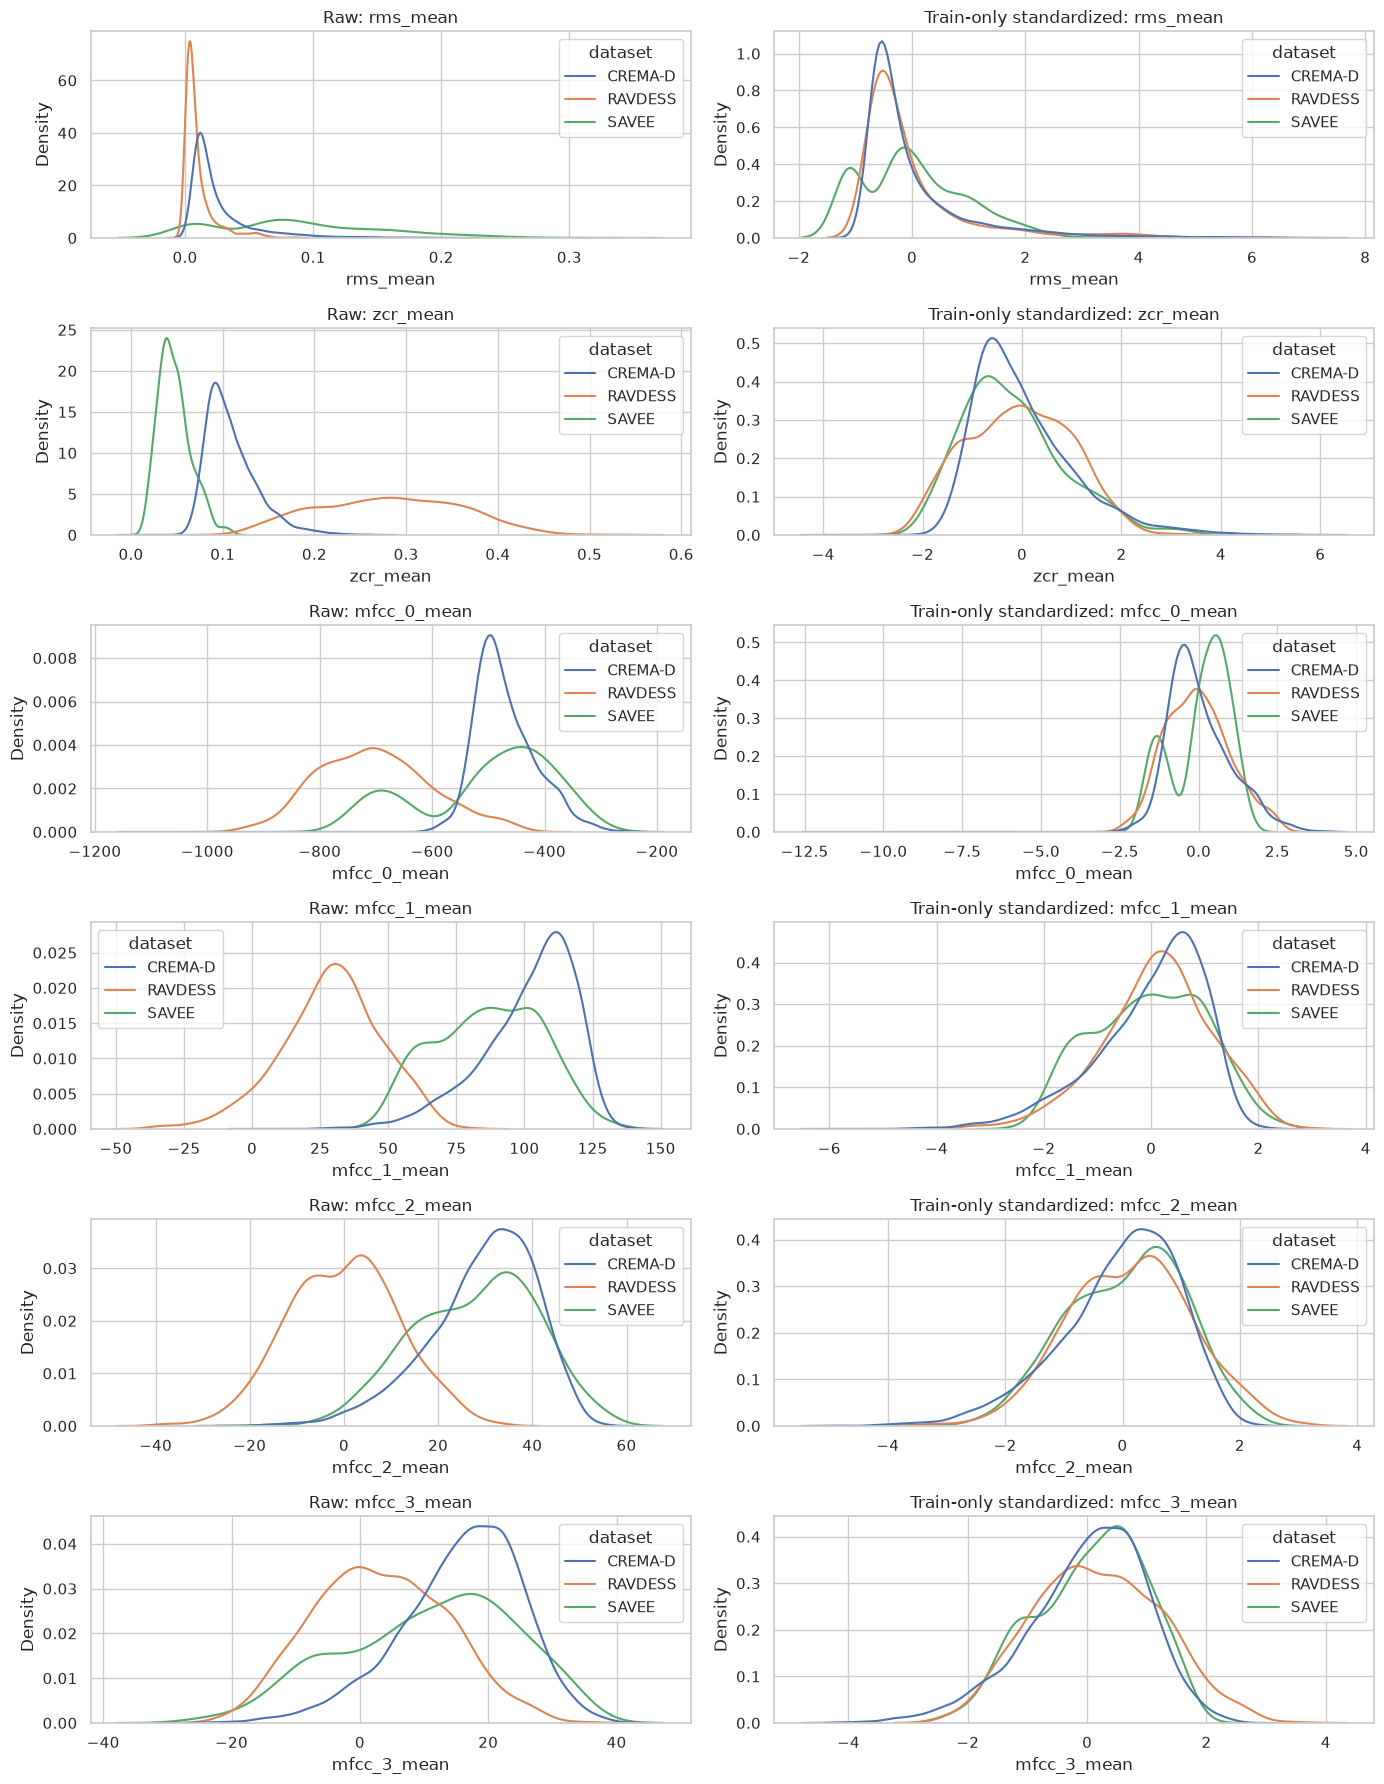

In [8]:
from sklearn.model_selection import train_test_split

standardized = samples.copy()
standardized['split'] = 'test'
for client in config.clients:
    name = client.dataset.name.value
    mask = standardized.dataset == name
    actors = np.sort(standardized.loc[mask, 'actor_id'].unique())
    train_actors, _ = train_test_split(
        actors, test_size=client.dataset.test_size,
        random_state=client.dataset.split_seed,
    )
    train_mask = mask & standardized.actor_id.isin(train_actors)
    standardized.loc[train_mask, 'split'] = 'train'
    mean = standardized.loc[train_mask, feature_columns].mean()
    std = standardized.loc[train_mask, feature_columns].std().replace(0, 1)
    standardized.loc[mask, feature_columns] = (
        standardized.loc[mask, feature_columns] - mean
    ) / std

key_features = [c for c in feature_columns if c in {'rms_mean', 'zcr_mean'}]
key_features += [c for c in feature_columns if c.startswith('mfcc_') and c.endswith('_mean')][:4]
fig, axes = plt.subplots(len(key_features), 2, figsize=(14, 3 * len(key_features)))
for row, feature in enumerate(key_features):
    sns.kdeplot(data=samples, x=feature, hue='dataset', common_norm=False, ax=axes[row, 0])
    axes[row, 0].set_title(f'Raw: {feature}')
    sns.kdeplot(data=standardized, x=feature, hue='dataset', common_norm=False, ax=axes[row, 1])
    axes[row, 1].set_title(f'Train-only standardized: {feature}')
plt.tight_layout()

## Многомерный MMD с перестановочной оценкой

Ширина RBF-ядра выбирается по эвристике медианного расстояния в объединённой выборке. Одинаковое ограничение числа примеров не позволяет крупнейшему корпусу доминировать в вычислениях. Перестановочный тест проверяет, является ли наблюдаемый MMD необычно большим при перестановочных метках домена. Анализ следует повторить с несколькими seed и указать ограничение выборки и ширину ядра.

In [9]:
def squared_distances(x, y):
    return np.maximum(
        (x * x).sum(1)[:, None] + (y * y).sum(1)[None, :] - 2 * x @ y.T, 0
    )

def mmd2_from_kernel(kernel, n_left):
    left = kernel[:n_left, :n_left]
    right = kernel[n_left:, n_left:]
    cross = kernel[:n_left, n_left:]
    left_term = (left.sum() - np.trace(left)) / (n_left * (n_left - 1))
    n_right = len(kernel) - n_left
    right_term = (right.sum() - np.trace(right)) / (n_right * (n_right - 1))
    return left_term + right_term - 2 * cross.mean()

def permutation_mmd(x, y, permutations=N_PERMUTATIONS, seed=SEED):
    rng = np.random.default_rng(seed)
    pooled = np.vstack([x, y])
    pooled = StandardScaler().fit_transform(pooled)
    distances = squared_distances(pooled, pooled)
    positive = distances[np.triu_indices_from(distances, k=1)]
    sigma2 = np.median(positive[positive > 0])
    kernel = np.exp(-distances / (2 * sigma2))
    observed = mmd2_from_kernel(kernel, len(x))
    null = []
    for _ in range(permutations):
        order = rng.permutation(len(pooled))
        null.append(mmd2_from_kernel(kernel[np.ix_(order, order)], len(x)))
    p_value = (1 + np.sum(np.asarray(null) >= observed)) / (permutations + 1)
    return observed, p_value, np.sqrt(sigma2)

rng = np.random.default_rng(SEED)
mmd_rows = []
for left, right in combinations(datasets, 2):
    pair = []
    for name in (left, right):
        values = samples.loc[samples.dataset == name, feature_columns].dropna().to_numpy()
        size = min(len(values), MAX_MMD_SAMPLES_PER_CORPUS)
        pair.append(values[rng.choice(len(values), size=size, replace=False)])
    size = min(map(len, pair))
    statistic, p_value, bandwidth = permutation_mmd(pair[0][:size], pair[1][:size])
    mmd_rows.append({
        'left': left, 'right': right, 'n_each': size,
        'mmd2': statistic, 'permutation_p': p_value, 'rbf_bandwidth': bandwidth,
    })
display(pd.DataFrame(mmd_rows).round(6))

,left,right,n_each,mmd2,permutation_p,rbf_bandwidth
0,CREMA-D,RAVDESS,500,0.381637,0.002,7.257524
1,CREMA-D,SAVEE,480,0.389779,0.002,7.546039
2,RAVDESS,SAVEE,480,0.332834,0.002,7.431905


## Можно ли определить корпус по акустическим сводкам?

Высокий попарный out-of-fold ROC-AUC означает, что принадлежность к корпусу восстанавливается по акустическим сводкам. Группировка фолдов по актёрам не позволяет классификатору использовать одного и того же говорящего при обучении и валидации. Это практическая оценка размера доменного сдвига, а не результат оценки качества целевого классификатора.

In [10]:
auc_rows = []
for left, right in combinations(datasets, 2):
    pair = samples[samples.dataset.isin([left, right])].dropna(subset=feature_columns).copy()
    x = pair[feature_columns].to_numpy()
    y = (pair.dataset == right).astype(int).to_numpy()
    groups = (pair.dataset.astype(str) + ':' + pair.actor_id.astype(str)).to_numpy()
    folds = min(5, pair.groupby('dataset').actor_id.nunique().min())
    splitter = StratifiedGroupKFold(n_splits=folds, shuffle=True, random_state=SEED)
    predictions = np.zeros(len(pair))
    for train_idx, test_idx in splitter.split(x, y, groups):
        model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
        model.fit(x[train_idx], y[train_idx])
        predictions[test_idx] = model.predict_proba(x[test_idx])[:, 1]
    auc_rows.append({'left': left, 'right': right, 'folds': folds, 'roc_auc': roc_auc_score(y, predictions)})
display(pd.DataFrame(auc_rows).round(4))

,left,right,folds,roc_auc
0,CREMA-D,RAVDESS,5,0.9999
1,CREMA-D,SAVEE,4,1.0000
2,RAVDESS,SAVEE,4,1.0000


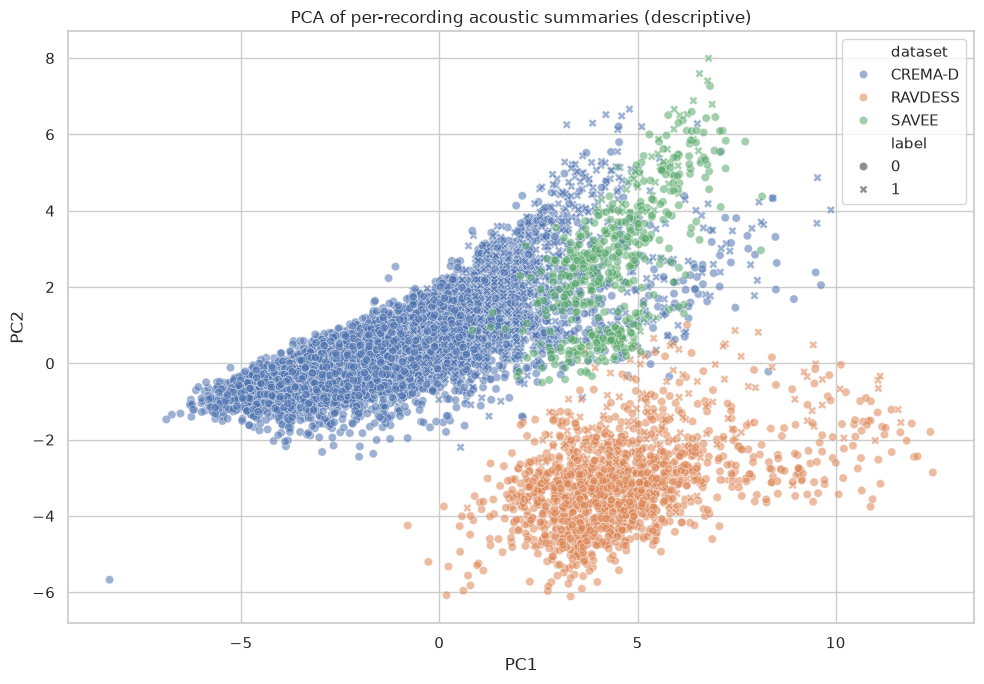

In [11]:
complete = samples.dropna(subset=feature_columns).copy()
scaled = StandardScaler().fit_transform(complete[feature_columns])
embedding = PCA(n_components=2, random_state=SEED).fit_transform(scaled)
plot_data = complete[['dataset', 'label', 'actor_id']].copy()
plot_data[['PC1', 'PC2']] = embedding
plt.figure(figsize=(10, 7))
sns.scatterplot(data=plot_data, x='PC1', y='PC2', hue='dataset', style='label', alpha=.55)
plt.title('PCA of per-recording acoustic summaries (descriptive)')
plt.tight_layout()

## Контрольный список отчётности

1. Сохранить разрешённую конфигурацию, манифест набора данных, seed, отчёт о потерях при извлечении и точные версии корпусов.
2. Указать покрытие по записям, актёрам, классам и длительности; не скрывать ошибки извлечения.
3. Привести попарные MMD², перестановочные p-значения, ширину ядра, ограничение размера выборки и неопределённость по повторным seed.
4. Привести размеры эффектов Вассерштейна и энергетического расстояния, а также скорректированные методом BH q-значения KS для заранее объявленного подмножества признаков.
5. Привести domain AUC с группировкой по актёрам, сравнить его с 0,5 и включить вариативность между фолдами в итоговое исследование.
6. Показать исходные распределения и распределения после стандартизации только по обучающей части. Рассматривать PCA/KDE как описательные методы, а не как проверки гипотез.
7. Делать вывод `межкорпусная неоднородность измерима` только при согласии нескольких независимых диагностик; до E1 не заключать, что федеративное обучение полезно.